In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.recommender.clustering import Clustering

In [2]:
df = pd.read_csv("../src/data_pipeline/data/processed/recommendation_features.csv")
df

,Ticker,PE_Ratio,Forward_PE,PBV_Ratio,PEG_Ratio,Beta,Debt_to_Equity,Current_Ratio,ROE,Profit_Margin,...,Sector_Communication Services,Sector_Consumer Cyclical,Sector_Consumer Defensive,Sector_Energy,Sector_Financial Services,Sector_Healthcare,Sector_Industrials,Sector_Real Estate,Sector_Technology,Sector_Utilities
0,A,-0.079726,0.029346,0.293381,1.26,0.798209,-0.548304,2.066,0.364186,0.18259,...,0,0,0,0,0,1,0,0,0,0
1,AAPL,0.682404,1.084995,5.199338,2.46,0.355242,0.464708,0.974,5.199338,0.27037,...,0,0,0,0,0,0,0,0,1,0
2,ABBV,1.643234,-0.630407,-5.199338,0.47,-1.486588,0.012575,0.671,5.199338,0.06910,...,0,0,0,0,0,1,0,0,0,0
3,ABNB,0.694965,0.701626,0.925867,1.35,0.494808,-1.060758,1.377,0.790165,0.20513,...,0,1,0,0,0,0,0,0,0,0
4,ABT,0.075543,-0.263662,-0.116680,1.41,-0.384802,-1.090872,1.202,0.000000,0.13905,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,XYZ,0.570171,-0.310931,-0.633924,0.84,5.199338,-0.763652,2.201,-1.072871,0.05397,...,0,0,0,0,0,0,0,0,1,0
499,YUM,0.258545,0.474068,-1.581725,1.99,-0.656184,0.012575,1.346,0.000000,0.18980,...,0,1,0,0,0,0,0,0,0,0
500,ZBH,0.104985,-1.000319,-1.034284,0.66,-0.752908,-0.355242,1.982,-1.108703,0.08566,...,0,0,0,0,0,1,0,0,0,0
501,ZBRA,0.164608,-0.839234,-0.058302,0.51,1.598419,0.150021,0.970,-0.406266,0.07765,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
def plot_clusters(df):
    
    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")
    
    # ดูแกน P/E Ratio เทียบกับ Beta
    plt.subplot(1, 2, 1)
    
    if 'PE_Ratio' in df.columns and 'Beta' in df.columns:
        sns.scatterplot(
            data=df, 
            x='PE_Ratio', 
            y='Beta', 
            hue='Style_Label',
            palette='Set1', 
            s=100, 
            alpha=0.7
        )
        
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.axvline(0, color='gray', linestyle='--', linewidth=1)
        
        plt.title('Stock Style: P/E Ratio vs Beta (Z-Score)', fontsize=14)
        plt.xlabel('P/E Ratio ', fontsize=12)
        plt.ylabel('Beta ', fontsize=12)
    
    # PCA บีบอัด 5 มิติเหลือ 2 มิติ
    plt.subplot(1, 2, 2)
    
    features = ['PE_Ratio', 'PBV_Ratio', 'Beta', 'ROE', 'Debt_to_Equity']
    features = [f for f in df.columns if f in features]
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(df[features])
    
    df['PCA_1'] = pca_result[:, 0]
    df['PCA_2'] = pca_result[:, 1]
    
    sns.scatterplot(
        data=df, 
        x='PCA_1', 
        y='PCA_2', 
        hue='Style_Label', 
        palette='Set1', 
        s=100, 
        alpha=0.8
    )
    
    plt.title('PCA Projection of Stock Clusters', fontsize=14)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    
    plt.tight_layout()
    plt.show()

In [4]:
clustering_engine = Clustering()

In [5]:
df_clustered, summary = clustering_engine.fit_and_label("../src/data_pipeline/data/processed/recommendation_features.csv")

กำลังโหลดข้อมูลจาก ../src/data_pipeline/data/processed/recommendation_features.csv...
กำลังรัน K-Means แบ่งหุ้นเป็น 3 กลุ่ม...

Z-score ของแต่ละกลุ่ม:
         PE_Ratio  PBV_Ratio  Beta   ROE  Debt_to_Equity
Cluster                                                 
0            0.62       4.03  0.61  3.56            2.55
1           -0.87      -0.82 -0.77 -0.37            0.30
2            0.98       0.36  0.90 -0.21           -0.87

สรุปจำนวนหุ้นในแต่ละสไตล์:
Style_Label
Defensive    257
Growth       209
Value         37
Name: count, dtype: int64


c:\Users\babxk\anaconda3\envs\lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


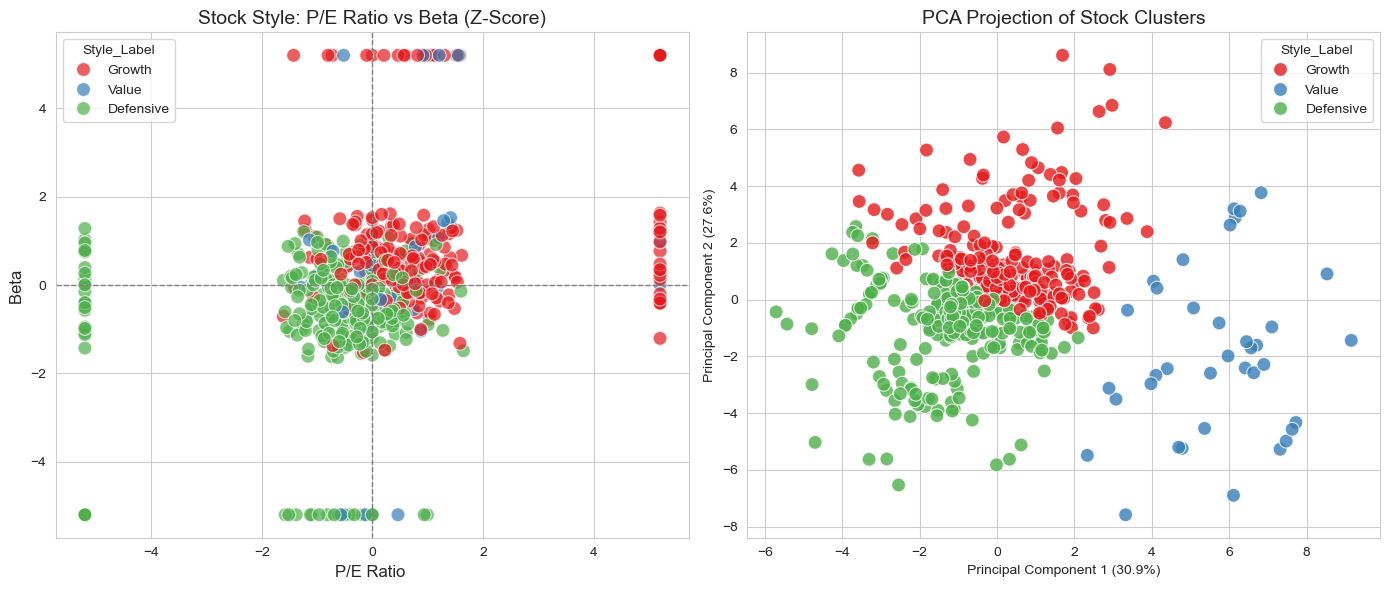

In [6]:
plot_clusters(df_clustered)

In [7]:
counts = df_clustered['Style_Label'].value_counts()

print("------- Clustering Report Group -------")
print(f"N Value         : {counts.get('Value', 0)}")
print(f"N Defensive     : {counts.get('Defensive', 0)}")
print(f"N Growth        : {counts.get('Growth', 0)}")
print(f"N Mixed/Neutral : {counts.get('Mixed/Neutral', 0)}")

------- Clustering Report Group -------
N Value         : 37
N Defensive     : 257
N Growth        : 209
N Mixed/Neutral : 0


In [11]:
df_clustered[df_clustered['Style_Label'] == "Value"]

,Ticker,PE_Ratio,Forward_PE,PBV_Ratio,PEG_Ratio,Beta,Debt_to_Equity,Current_Ratio,ROE,Profit_Margin,...,Sector_Financial Services,Sector_Healthcare,Sector_Industrials,Sector_Real Estate,Sector_Technology,Sector_Utilities,Cluster,Style_Label,PCA_1,PCA_2
1,AAPL,0.682404,1.084995,5.199338,2.46,0.355242,0.464708,0.974,5.199338,0.27037,...,0,0,0,0,1,0,0,Value,6.712209,-1.609593
28,AMGN,-0.155719,-0.293381,1.426077,2.35,-1.124338,5.199338,1.140,5.199338,0.20982,...,0,1,0,0,0,0,0,Value,4.786712,-5.239408
39,APP,1.063052,0.563173,5.199338,1.38,5.199338,0.887923,3.322,5.199338,0.60827,...,0,0,0,0,0,0,0,Value,8.529976,0.904483
51,BA,5.199338,5.199338,5.199338,1.72,0.004192,5.199338,1.176,5.199338,0.02460,...,0,0,1,0,0,0,0,Value,9.155397,-1.436041
95,CL,0.460701,0.370482,5.199338,1.48,-5.199338,5.199338,0.833,5.199338,0.10460,...,0,0,0,0,0,0,0,Value,6.112481,-6.896306
109,COR,0.750870,-0.155719,5.199338,0.77,-0.550553,5.199338,0.916,5.199338,0.00499,...,0,1,0,0,0,0,0,Value,7.725055,-4.330816
110,COST,1.183148,5.199338,5.199338,5.52,-0.043328,-0.409362,1.058,0.758485,0.02986,...,0,0,0,0,0,0,0,Value,4.045917,0.651825
194,FIX,1.359737,1.530667,5.199338,1.44,1.403274,-0.671861,1.211,1.318636,0.11235,...,0,0,1,0,0,0,0,Value,4.807671,1.407310
199,FTNT,0.651486,0.753194,5.199338,2.01,0.067117,0.311681,1.172,5.199338,0.27257,...,0,0,0,0,1,0,0,Value,6.566878,-1.702019
202,GDDY,-1.298895,-5.199338,5.199338,0.68,-0.046125,5.199338,0.615,5.199338,0.17673,...,0,0,0,0,1,0,0,Value,7.316321,-5.273053


In [ ]:
class PortfolioRecommender:
    def __init__(self, risk_data_path):
        print("โหลด Risk Engine (Correlation Matrix)...")
        # โหลดผลตอบแทนรายวันเพื่อเตรียมคำนวณความสัมพันธ์
        self.df_risk = pd.read_csv(risk_data_path)
        
        # ตั้ง Date ให้เป็น Index เพื่อง่ายต่อการคำนวณ Correlation
        if 'Date' in self.df_risk.columns:
            self.df_risk.set_index('Date', inplace=True)

    def get_recommendations(self, current_portfolio, df_clustered, top_n=5):
        """
        วิเคราะห์พอร์ตและแนะนำหุ้นเพื่อคานความเสี่ยง (Diversification)
        """
        print(f"\nกำลังวิเคราะห์พอร์ตของคุณ: {current_portfolio}")

        user_stocks = df_clustered[df_clustered['Ticker'].isin(current_portfolio)]
        
        if user_stocks.empty:
            print("ไม่พบข้อมูลหุ้นในพอร์ตของคุณในระบบ")
            return pd.DataFrame()
            
        user_styles = user_stocks['Style_Label'].unique().tolist()
        print(f"   > หุ้นของคุณกระจุกอยู่ในสไตล์: {user_styles}")

        candidates_df = df_clustered[~df_clustered['Style_Label'].isin(user_styles)]

        if candidates_df.empty:
            print(" พอร์ตคุณกระจายความเสี่ยงครบทุกสไตล์แล้ว! จะค้นหาจากหุ้นทั้งตลาดแทน")
            candidates_df = df_clustered[~df_clustered['Ticker'].isin(current_portfolio)]

        candidates_list = candidates_df['Ticker'].tolist()
        print(f"   > คัดกรอง Candidate เบื้องต้นได้: {len(candidates_list)} ตัว")

        print("   > กำลังคำนวณ Correlation (ค้นหาจิ๊กซอว์ตัวที่หายไป)...")
        corr_matrix = self.df_risk.corr()

        valid_portfolio = [t for t in current_portfolio if t in corr_matrix.columns]

        candidate_scores = []
        for cand in candidates_list:
            if cand in corr_matrix.columns:
                avg_corr = corr_matrix.loc[cand, valid_portfolio].mean()
                candidate_scores.append((cand, avg_corr))

        candidate_scores.sort(key=lambda x: x[1])

        best_candidates = [score[0] for score in candidate_scores[:top_n]]

        result_df = df_clustered[df_clustered['Ticker'].isin(best_candidates)][['Ticker', 'Style_Label', 'Beta', 'PE_Ratio']]
        
        result_df['Corr_to_Port'] = [score[1] for score in candidate_scores[:top_n]]
        
        result_df = result_df.sort_values(by='Corr_to_Port').reset_index(drop=True)

        print("\n[ผลลัพธ์] หุ้นแนะนำเพื่อลดความเสี่ยงพอร์ต (เรียงจากดีที่สุด):")
        print(result_df.to_string(index=False))

        return result_df

In [17]:
my_portfolio = ['AAPL', 'MSFT']

In [18]:
recommender = PortfolioRecommender(risk_data_path="../data/processed/risk_returns.csv")

🤖 โหลด Risk Engine (Correlation Matrix)...


In [19]:
best_stocks_to_buy = recommender.get_recommendations(my_portfolio, df_clustered, top_n=5)


🎯 กำลังวิเคราะห์พอร์ตของคุณ: ['AAPL', 'MSFT']
   > หุ้นของคุณกระจุกอยู่ในสไตล์: ['Value', 'Growth']
   > คัดกรอง Candidate เบื้องต้นได้: 257 ตัว
   > 🧮 กำลังคำนวณ Correlation (ค้นหาจิ๊กซอว์ตัวที่หายไป)...

✨ [ผลลัพธ์] หุ้นแนะนำเพื่อลดความเสี่ยงพอร์ต (เรียงจากดีที่สุด):
Ticker Style_Label      Beta  PE_Ratio  Corr_to_Port
   AWK   Defensive -0.492914 -0.241246     -0.245181
   DUK   Defensive -1.140254 -0.560335     -0.235895
    ED   Defensive -1.643234 -0.630407     -0.204833
   EXC   Defensive -1.027154 -0.823369     -0.183429
    SO   Defensive -1.338904 -0.232624     -0.177477
